<a href="https://colab.research.google.com/github/ZahranAzariaAnvaya/BigData26_A_2411531005_ZahranAzariaAnvaya/blob/main/Praktikum1/BD_A_T01_2411531005_Zahran_Azaria_Anvaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Persiapan Environment**

In [1]:
import sys, platform, multiprocessing

print("Python :", sys.version.split()[0])
print("OS     :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

Python : 3.13.15
OS     : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA  = "/content/data"                             # sementara, cepat
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"  # folder yang sama dengan praktikum,
                                                            # supaya artefak tugas & praktikum
                                                            # tersimpan berdampingan
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['agregasi_per_jam_bulan_lain.csv', 'agregasi_per_jam_bulan_lain.parquet', 'distribusi_per_jam_bulan_lain.png', 'perbandingan_dua_bulan.png', 'pengukuran_kinerja_tugas.csv', 'agregasi_per_jam.csv', 'distribusi_per_jam.png', 'agregasi_per_jam.parquet', 'pengukuran_kinerja.csv', 'studi_kasus_permintaan.png', 'studi_kasus_tarif_per_menit.png']


In [3]:
import time, psutil

proses = psutil.Process(os.getpid())
catatan_tugas = []   # catatan pengukuran khusus notebook tugas ini

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan_tugas.append({"langkah": label, "detik": round(detik, 2),
                           "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

## **1. Mengganti Dataset**

Ulangi langkah J-4 sampai J-10 menggunakan data bulan Juli 2023. Sebelum melanjutkan, periksa dulu apakah skema kolomnya sama dengan bulan Januari.

In [4]:
import urllib.request
import pyarrow.parquet as pq
import pandas as pd

URL_B = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
         "yellow_tripdata_2023-07.parquet")
PATH_B = os.path.join(DIR_KERJA, "yellow_tripdata_2023-07.parquet")

if not os.path.exists(PATH_B):
    ukur("unduh dataset bulan lain", lambda: urllib.request.urlretrieve(URL_B, PATH_B))

meta_b = pq.ParquetFile(PATH_B).metadata
print("Ukuran file :", round(os.path.getsize(PATH_B) / 1024**2, 1), "MB")
print("Jumlah baris:", f"{meta_b.num_rows:,}")
print("Nama kolom  :", pq.ParquetFile(PATH_B).schema.names)

[unduh dataset bulan lain] 0.96 s | RSS +1.0 MB
Ukuran file : 46.1 MB
Jumlah baris: 2,907,108
Nama kolom  : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [5]:
KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

df_b = ukur("baca kolom terpilih (bulan lain)",
            lambda: pd.read_parquet(PATH_B, columns=KOLOM))
print("Dimensi:", df_b.shape)
df_b.head()

[baca kolom terpilih (bulan lain)] 0.82 s | RSS +206.2 MB
Dimensi: (2907108, 8)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-07-01 00:29:59,2023-07-01 00:40:15,1.0,1.80,1,12.1,5.10,22.20
1,2023-07-01 00:03:25,2023-07-01 00:23:44,1.0,2.31,2,19.1,0.00,24.10
2,2023-07-01 00:38:29,2023-07-01 00:48:53,1.0,2.36,1,13.5,3.70,22.20
3,2023-07-01 00:14:16,2023-07-01 00:29:13,1.0,4.36,1,19.8,4.96,29.76
4,2023-07-01 00:11:15,2023-07-01 00:20:47,0.0,1.60,1,11.4,3.25,19.65


In [6]:
# Pembersihan data, memakai threshold yang sama dengan J-6 di notebook praktikum
df_b["durasi_menit"] = (df_b["tpep_dropoff_datetime"] -
                         df_b["tpep_pickup_datetime"]).dt.total_seconds() / 60

layak_b = (
    (df_b["trip_distance"] > 0) & (df_b["trip_distance"] < 100) &
    df_b["durasi_menit"].between(1, 180) &
    (df_b["total_amount"] > 0)
)
bersih_b = df_b.loc[layak_b].copy()
print(f"{len(df_b):,} baris -> {len(bersih_b):,} baris  (dibuang {len(df_b)-len(bersih_b):,})")

2,907,108 baris -> 2,817,657 baris  (dibuang 89,451)


In [7]:
# Agregasi per jam & penyimpanan artefak
bersih_b["jam"] = bersih_b["tpep_pickup_datetime"].dt.hour

agregasi_b = (bersih_b
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi_b.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam_bulan_lain.csv", index=False)
agregasi_b.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam_bulan_lain.parquet", index=False)
agregasi_b

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,85987,4.45,14.82,31.05,22.20
1,1,59980,4.04,13.52,28.64,21.36
2,2,40812,3.79,12.82,27.08,21.10
3,3,26000,4.02,12.83,27.92,21.30
4,4,16637,5.60,14.62,34.92,24.10
5,5,16913,6.67,15.65,39.74,23.90
6,6,38422,5.11,14.51,32.13,19.25
7,7,69358,4.10,14.57,28.60,18.80
8,8,103647,3.53,15.30,27.34,19.32
9,9,118788,3.40,15.68,27.28,19.90


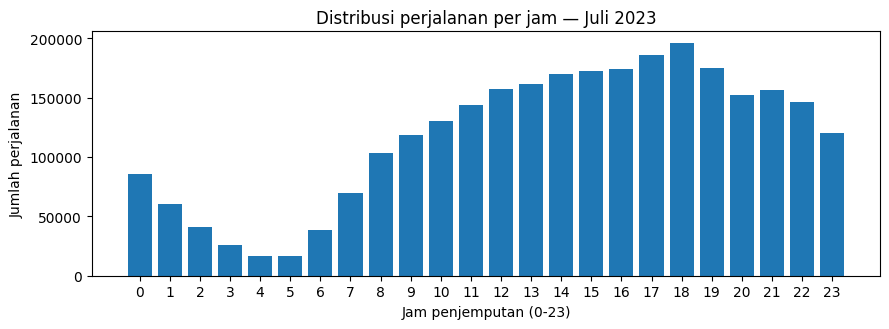

In [8]:
# Visualisasi
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi_b["jam"], agregasi_b["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam — Juli 2023")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam_bulan_lain.png", dpi=150)
plt.show()

## **2.  Membandingkan Dua Bulan**

Untuk membandingkan dengan bulan pada notebook praktikum (Januari 2023), artefak agregasi_per_jam.csv yang sudah disimpan oleh notebook praktikum di folder Drive yang sama dibaca kembali, bukan menghitung ulang dari awal, karena hasilnya sudah tersimpan disana.

In [9]:
try:
    agregasi_jan = pd.read_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv")
except FileNotFoundError:
    print("File dari notebook praktikum belum ada, menghitung ulang dari awal...")
    URL_JAN = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
               "yellow_tripdata_2023-01.parquet")
    PATH_JAN = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")
    if not os.path.exists(PATH_JAN):
        urllib.request.urlretrieve(URL_JAN, PATH_JAN)

    df_jan = pd.read_parquet(PATH_JAN, columns=KOLOM)
    df_jan["durasi_menit"] = (df_jan["tpep_dropoff_datetime"] - df_jan["tpep_pickup_datetime"]).dt.total_seconds() / 60
    layak_jan = ((df_jan["trip_distance"] > 0) & (df_jan["trip_distance"] < 100) &
                 df_jan["durasi_menit"].between(1, 180) & (df_jan["total_amount"] > 0))
    bersih_jan = df_jan.loc[layak_jan].copy()
    bersih_jan["jam"] = bersih_jan["tpep_pickup_datetime"].dt.hour
    agregasi_jan = (bersih_jan.groupby("jam").agg(jumlah_perjalanan=("total_amount","size")).reset_index())

perbandingan = agregasi_jan[["jam", "jumlah_perjalanan"]].merge(
    agregasi_b[["jam", "jumlah_perjalanan"]], on="jam",
    suffixes=("_jan", "_jul"))
perbandingan

,jam,jumlah_perjalanan_jan,jumlah_perjalanan_jul
0,0,82289,85987
1,1,57766,59980
2,2,40445,40812
3,3,26146,26000
4,4,16618,16637
5,5,16940,16913
6,6,42300,38422
7,7,84569,69358
8,8,114064,103647
9,9,127988,118788


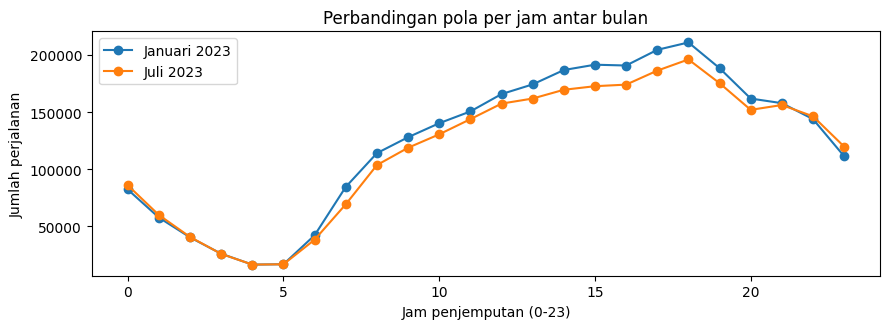

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(perbandingan["jam"], perbandingan["jumlah_perjalanan_jan"], marker="o", label="Januari 2023")
ax.plot(perbandingan["jam"], perbandingan["jumlah_perjalanan_jul"], marker="o", label="Juli 2023")
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Perbandingan pola per jam antar bulan")
ax.legend()
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/perbandingan_dua_bulan.png", dpi=150)
plt.show()

## **3. Laporan Kinerja**

lampirkan catatan pengukuran waktu & memori dari langkah-langkah di notebook tugas ini (catatan_tugas), lalu urutkan untuk melihat langkah mana yang paling mahal.

In [11]:
kinerja_tugas = pd.DataFrame(catatan_tugas)
kinerja_tugas.to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja_tugas.csv", index=False)
kinerja_tugas.sort_values("detik", ascending=False)

,langkah,detik,delta_rss_mb
0,unduh dataset bulan lain,0.96,1.0
1,baca kolom terpilih (bulan lain),0.82,206.2
